In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

DATA_DIR = Path("../data")

train = pd.read_csv(DATA_DIR / "train.csv")
validation = pd.read_csv(DATA_DIR / "validation.csv")
test = pd.read_csv(DATA_DIR / "test_input.csv")

train["datetime"] = pd.to_datetime(
    train["datetime"], format="%d-%m-%Y %H:%M"
)
validation["datetime"] = pd.to_datetime(
    validation["datetime"], format="%d-%m-%Y %H:%M"
)
test["datetime"] = pd.to_datetime(
    test["datetime"], format="%d-%m-%Y %H:%M"
)

targets = [
    "nat_demand",
    "load_tocumen_mwh",
    "load_santiago_mwh",
    "load_david_mwh"
]

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (34343, 51)
Validation: (7248, 51)
Test: (2352, 47)


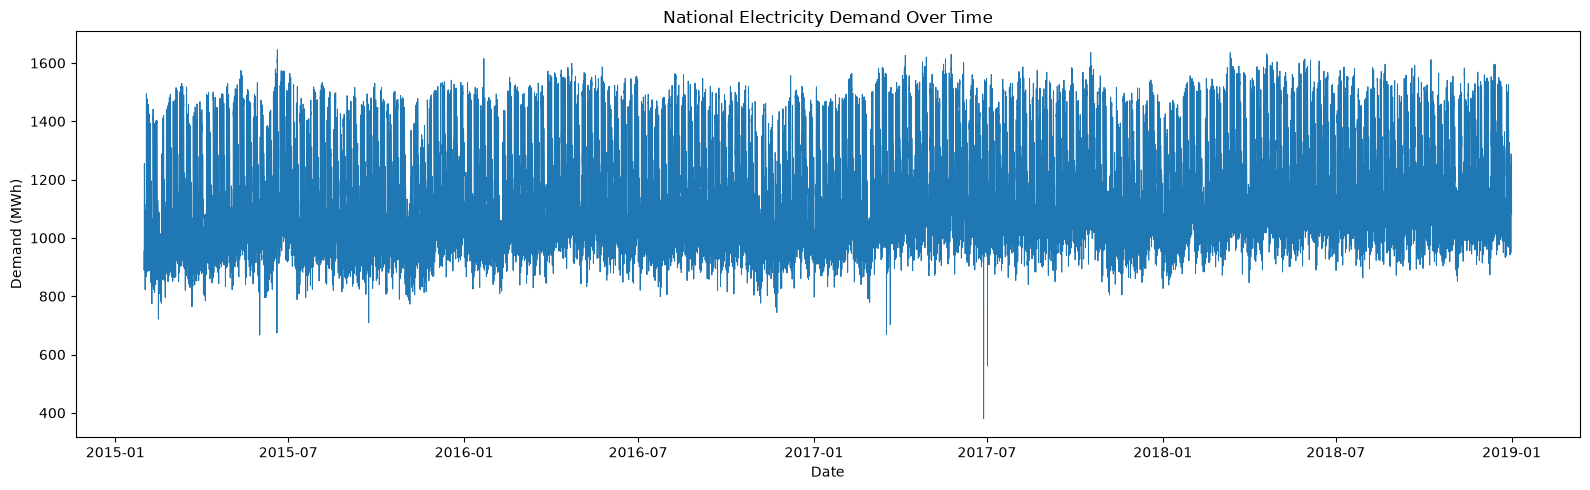

In [2]:
plt.figure(figsize=(16, 5))

plt.plot(
    train["datetime"],
    train["nat_demand"],
    linewidth=0.7
)

plt.title("National Electricity Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand (MWh)")
plt.tight_layout()
plt.show()

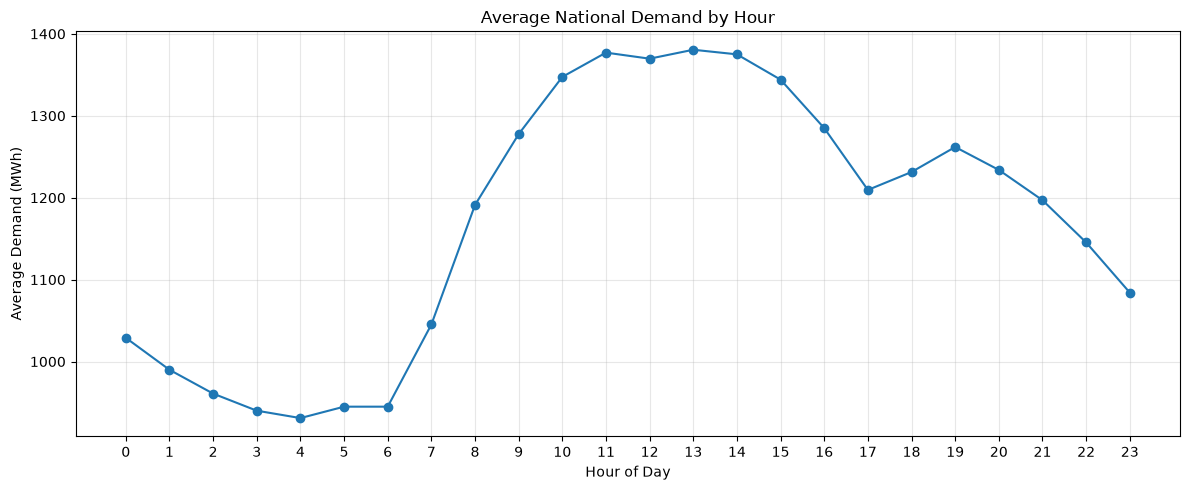

In [3]:
hourly_profile = (
    train.groupby("hourOfDay")["nat_demand"]
    .mean()
)

plt.figure(figsize=(12, 5))
plt.plot(hourly_profile.index, hourly_profile.values, marker="o")

plt.title("Average National Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MWh)")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

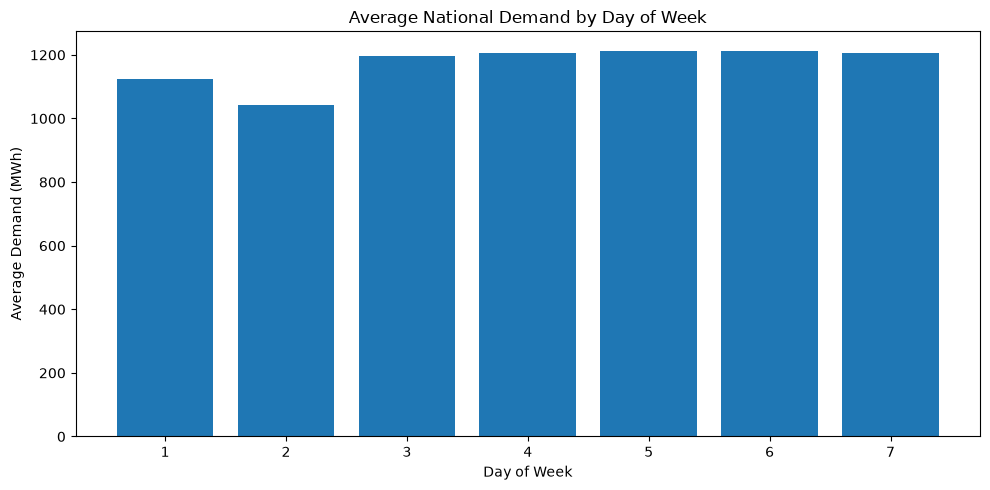

In [4]:
dow_profile = (
    train.groupby("dayOfWeek")["nat_demand"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.bar(dow_profile.index, dow_profile.values)

plt.title("Average National Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand (MWh)")
plt.xticks(range(1, 8))
plt.tight_layout()
plt.show()

In [5]:
peak_threshold = train["nat_demand"].quantile(0.95)

peak_data = train[train["nat_demand"] >= peak_threshold]

print("95th percentile demand:", round(peak_threshold, 2))
print("Peak observations:", len(peak_data))

print("\nPeak demand by hour:")
display(
    peak_data.groupby("hourOfDay")["nat_demand"]
    .agg(["count", "mean", "max"])
    .sort_values("count", ascending=False)
)

95th percentile demand: 1495.22
Peak observations: 1718

Peak demand by hour:


,count,mean,max
hourOfDay,,,
14,415,1534.797007,1645.4773
13,411,1533.916677,1639.0955
11,291,1528.703172,1611.7683
12,264,1526.279456,1603.0430
15,193,1527.985196,1615.2451
10,129,1520.145039,1565.0586
16,14,1508.310686,1527.8305
9,1,1509.830900,1509.8309


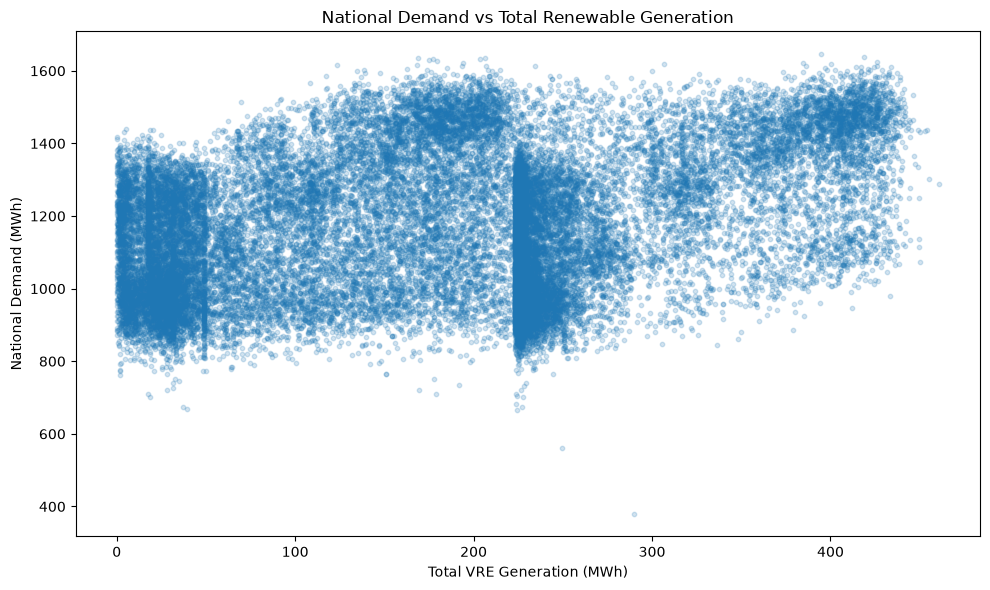

In [6]:
plt.figure(figsize=(10, 6))

plt.scatter(
    train["total_vre_gen_mwh"],
    train["nat_demand"],
    alpha=0.2,
    s=10
)

plt.title("National Demand vs Total Renewable Generation")
plt.xlabel("Total VRE Generation (MWh)")
plt.ylabel("National Demand (MWh)")
plt.tight_layout()
plt.show()

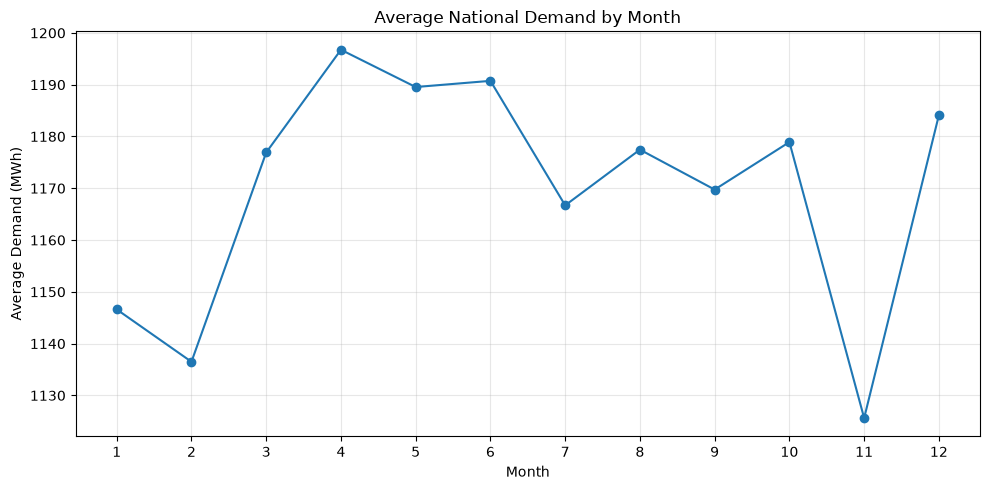

In [7]:
# Monthly demand profile
train["month"] = train["datetime"].dt.month

monthly_profile = train.groupby("month")["nat_demand"].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_profile.index, monthly_profile.values, marker="o")
plt.title("Average National Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand (MWh)")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
weather_features = [
    "T2M_toc", "QV2M_toc", "TQL_toc", "W2M_toc",
    "T2M_san", "QV2M_san", "TQL_san", "W2M_san",
    "T2M_dav", "QV2M_dav", "TQL_dav", "W2M_dav"
]

renewable_features = [
    "tocumen_wind_gen_mwh", "santiago_wind_gen_mwh",
    "david_wind_gen_mwh", "tocumen_solar_gen_mwh",
    "santiago_solar_gen_mwh", "david_solar_gen_mwh",
    "total_wind_gen_mwh", "total_solar_gen_mwh",
    "total_vre_gen_mwh"
]

In [10]:
# Weather and renewable correlation with national demand
eda_features = weather_features + renewable_features

corr = train[eda_features + ["nat_demand"]].corr()["nat_demand"].drop("nat_demand")
corr = corr.sort_values()

display(corr.to_frame("Correlation").round(3))

,Correlation
tocumen_wind_gen_mwh,-0.055
total_wind_gen_mwh,-0.048
W2M_dav,-0.042
QV2M_toc,-0.028
david_wind_gen_mwh,-0.012
QV2M_dav,0.011
QV2M_san,0.049
TQL_dav,0.061
W2M_toc,0.070
TQL_toc,0.104


In [11]:
calendar_effects = train.groupby(
    ["weekend", "holiday", "school"]
)["nat_demand"].mean().reset_index()

display(calendar_effects.round(2))

,weekend,holiday,school,nat_demand
0,0,0,0,1208.78
1,0,0,1,1217.58
2,0,1,0,1033.18
3,0,1,1,1057.58
4,1,0,0,1084.38
5,1,0,1,1088.12
6,1,1,0,1018.97
7,1,1,1,1036.60


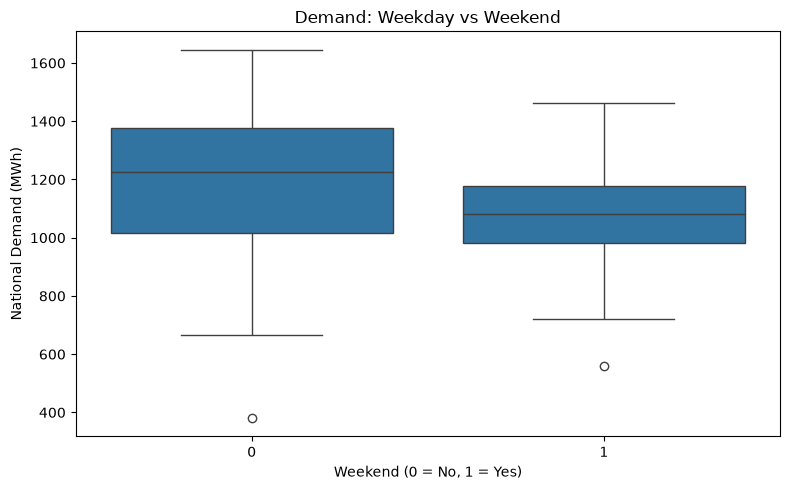

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=train,
    x="weekend",
    y="nat_demand"
)

plt.title("Demand: Weekday vs Weekend")
plt.xlabel("Weekend (0 = No, 1 = Yes)")
plt.ylabel("National Demand (MWh)")
plt.tight_layout()
plt.show()

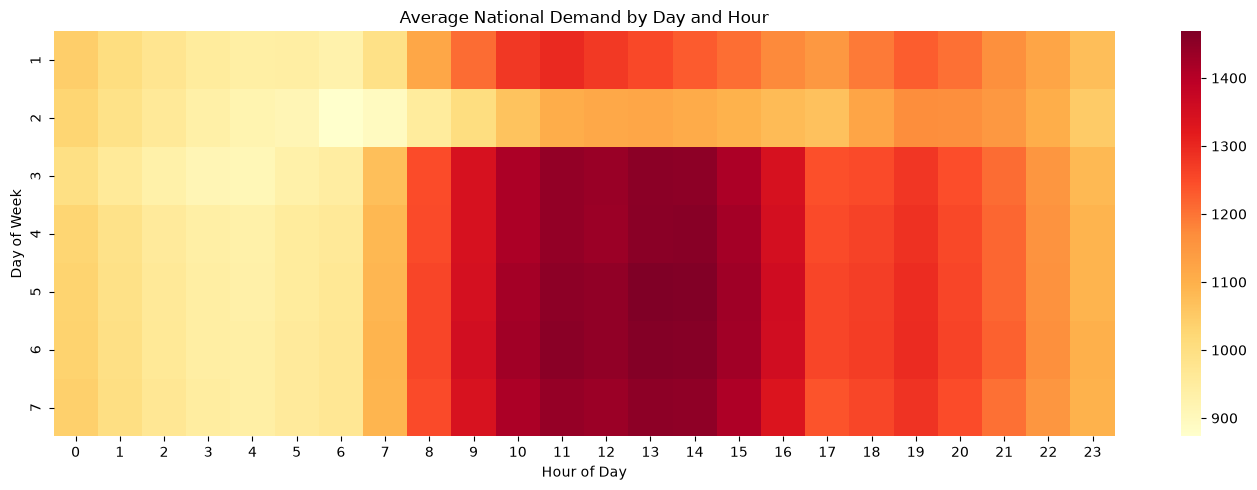

In [13]:
pivot = train.pivot_table(
    index="dayOfWeek",
    columns="hourOfDay",
    values="nat_demand",
    aggfunc="mean"
)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, annot=False, cmap="YlOrRd")
plt.title("Average National Demand by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

## Conclusion
In this notebook, we explored the main demand patterns in the training data. The analysis showed clear hourly and weekly behavior, with demand generally lower during the early morning and higher during the daytime, especially around the late morning to afternoon period. We also observed a secondary increase in demand during the evening.
Weekends and holidays generally showed lower demand than regular weekdays, while the school indicator had a smaller effect. The weather analysis showed that temperature has a noticeable relationship with demand, and solar generation also showed a strong correlation.
The day hour heatmap confirmed that demand patterns depend on the combination of the day of the week and the hour, so we should capture these interactions during feature engineering.
Overall, the EDA confirmed that historical demand, time/calendar patterns, temperature and renewable generation information are the main areas worth exploring further. The next step is to engineer additional features from these signals and test whether they actually improve our baseline model.